# Helios 04 — Distributed Sharding & Mosaic

**Solar site-selection, step 4: scaling to regions.** Notebook 01 wrote the entire SF
building pyramid into a **single** PMTiles archive — perfect for a city. When the area
grows to statewide or continental scale, a single archive becomes a multi-gigabyte
monolith: slow to re-generate when a neighbourhood updates, and a bottleneck for
parallel workers.

This notebook demonstrates the **distributed sharding** alternative:

1. **Assign every tile to a coarse parent shard** using a bit-shift on `(z, x, y)`.
   Each shard key corresponds to one parent tile in the slippy-map quadtree.
2. **One PMTiles archive per shard** — `gbx_pmtiles_agg` grouped by `shard` produces
   one bounded archive per key instead of one global archive.
3. **Mosaic catalog** — a lightweight `mosaic.json` (and a Delta table) maps each
   shard's bounds and zoom range to its Volume path. A MapLibre + pmtiles.js client
   fetches whichever shard(s) the viewport intersects; the browser assembles the full
   map client-side without any tile-proxy server.

**Key rules from the sharding mental model:**
- **Buffer the source query** so features straddling a boundary are not clipped inside
  either shard's archive. These demo notebooks use a small AOI and omit source buffering;
  a production pipeline must expand the source geometry query by a small buffer so that
  features near a shard boundary are fetched in full before tiling clips them to each
  tile's boundary.
- **Output tiles must not overlap across shards** — the same `(z, x, y)` must appear
  in exactly one archive. The bit-shift assignment guarantees this: every tile's parent
  at `shard_z` is unique.
- **Atomic re-generation** — if a single neighbourhood updates, only the one shard
  that contains it needs to be re-generated; the rest of the catalog is untouched.

> Runs on the **lightweight tier (Serverless)** by default. See `config_nb` for the
> heavyweight switch.

---
_Last Modified:_ June 29, 2026

![Distributed PMTiles sharding diagram](https://raw.githubusercontent.com/databrickslabs/geobrix/main/resources/images/diagrams/helios/helios-04.png)

In [0]:
%run ./config_nb

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


... skipping spark.conf.set(spark.sql.adaptive.coalescePartitions.enabled) [Serverless?]: AnalysisException


True

... catalog: 'geospatial_docs' (USE)
... schema: 'geobrix' (CREATE / USE)


... ETL_DIR: '/Volumes/geospatial_docs/geobrix/data'
... HELIOS_DIR: '/Volumes/geospatial_docs/geobrix/data/helios' (MKDIRS)
... SF_CITY_BBOX: (-122.52, 37.7, -122.35, 37.83)


In [0]:
# Toggles (also overridable per-notebook in a cell right after %run ./config_nb):
FORCE_REBUILD = False      # True (default False) -> re-create tables / re-download / re-tile (skip-guards off)
INTERACTIVE_PLOTS = False  # False (default) -> fast static maps that render on GitHub; True -> interactive maps

## 1. Build the tile rows

We load the same SF building footprints as Notebook 01 and run `gbx_st_asmvt_pyramid`
to produce the flat `(z, x, y, mvt_bytes)` tile pyramid.

We extend the zoom range to **z11–z16** so the MVT rows include tiles at `shard_z=11`
itself (needed so the shard assignment is non-trivial even at the coarsest zoom).

In [0]:
import json
import os

# Skip the network discover + download once the AOI is staged in Delta
# (overture_buildings_meta), unless FORCE_REBUILD -- mirrors NB01.
_overture_staged = spark.catalog.tableExists("overture_buildings_meta")
_need_overture = FORCE_REBUILD or not _overture_staged

assets = None
if not _need_overture:
    print("... overture_buildings_meta already staged (skip discover; set FORCE_REBUILD=True to refresh)")
else:
    assets = overture.discover(SF_CITY_BBOX, themes=["buildings"])
    print(f"... {assets.count()} intersecting building assets")

... overture_buildings_meta already staged (skip discover; set FORCE_REBUILD=True to refresh)


In [0]:
OVERTURE_DIR = f"{HELIOS_DIR}/overture"

if not _need_overture:
    meta = spark.table("overture_buildings_meta")
    print("... overture_buildings_meta already staged (skip download; FORCE_REBUILD=False)")
else:
    meta = overture.download(
        assets, OVERTURE_DIR,
        bbox=SF_CITY_BBOX,
        force=FORCE_REBUILD,         # AOI bbox -> overturemaps CLI server-side pushdown (Serverless-safe)
        table="overture_buildings_meta",
        validate=True,
        partitions=64,
    )

... overture_buildings_meta already staged (skip download; FORCE_REBUILD=False)


In [0]:
buildings = (
    overture.read("overture_buildings_meta", theme="buildings", type="building", bbox=SF_CITY_BBOX)
            .select(F.col("id").alias("feature_id"), F.col("geometry"))
)
print(f"... {buildings.count():,} building footprints in the AOI")

... 172,809 building footprints in the AOI


In [0]:
# Serverless fan-out: the overturemaps CLI writes ONE parquet, so `buildings` lands in
# only a few partitions and the per-feature pyramid UDTF would run on ~3 tasks. A column
# key is REQUIRED: number-only repartition(N) is AQE-coalesced back to serial on Serverless.
buildings = buildings.repartition(64, "feature_id")
buildings.createOrReplaceTempView("sf_buildings_nb04")

# gbx_st_asmvt_pyramid (light tier — Python UDTF):
#   gbx_st_asmvt_pyramid(geom_wkb, attrs, min_z, max_z [, layer_name [, extent]])
# Output columns (flat): z INTEGER, x INTEGER, y INTEGER, mvt_bytes BINARY
#
# Zoom range z11-z16: includes tiles at shard_z=11 itself so the shard assignment
# produces non-trivial results even at the coarsest zoom level.
mvt = spark.sql("""
    SELECT t.z, t.x, t.y, t.mvt_bytes
    FROM sf_buildings_nb04,
         LATERAL gbx_st_asmvt_pyramid(
             geometry,
             named_struct('feature_id', feature_id),
             11, 16,
             'buildings'
         ) AS t
""")

sf_mvt_nb04 = finalize_delta(mvt, "sf_buildings_mvt_shards_src")
print(f"... {sf_mvt_nb04.count():,} (z,x,y) MVT rows across z11-z16")

... table sf_buildings_mvt_shards_src exists (skip; FORCE_REBUILD=False)
root
 |-- z: integer (nullable = true)
 |-- x: integer (nullable = true)
 |-- y: integer (nullable = true)
 |-- mvt_bytes: binary (nullable = true)

... 1,059,740 (z,x,y) MVT rows across z11-z16


## 2. Assign each tile to a coarse parent shard

The shard key is derived by right-shifting `x` and `y` to a coarser zoom level
(`shard_z`). For any tile at zoom `z >= shard_z`:

```
sx = x >> (z - shard_z)   # parent tile X at shard_z
sy = y >> (z - shard_z)   # parent tile Y at shard_z
shard = f"{shard_z}_{sx}_{sy}"
```

This is a **lossless spatial partition**: every tile maps to exactly one parent shard
tile, and two tiles that share the same parent will always land in the same shard.
Output tiles are therefore **non-overlapping across shards** by construction.

**`shard_z = 11` for this SF demo.** The SF bounding box spans two z11 tile columns
(x = 326, 327) and two rows (y = 791, 792) — four candidate parent tiles. A shard archive
is produced only where tiles actually exist, so the SW tile `11_326_792` (open water off
the coast) yields **no archive**, and the NW tile `11_326_791` (Presidio / coastline) is
nearly empty. The two eastern tiles — `11_327_791` (dense downtown) and `11_327_792` —
hold the city. Expect **three archives**, dominated by the downtown shard. Shards form
only where there is data.

> At continental scale you would use a coarser `shard_z` (e.g. 6 for ~64 world tiles,
> or 3 for ~8), keeping each archive in the 100 MB–2 GB management sweet spot and
> limiting per-archive tile counts to a processable number.

In [0]:
# shard_z=11 splits the SF AOI into 4 parent tiles: x∈{326,327}, y∈{791,792}.
# Each tile at zoom z is right-shifted by (z - shard_z) to find its parent.
# Tiles with z < shard_z are excluded here since our pyramid starts at z=11=shard_z.
SHARD_Z = 11

# F.shiftright(col, numBits) requires a Python int literal for numBits, not a Column.
# Since the shift amount is z - SHARD_Z (varies per row) we use F.expr with inline SQL
# arithmetic — shiftright in Spark SQL accepts Column expressions for both operands.
shard_key = F.expr(
    f"concat('{SHARD_Z}_', shiftright(x, z - {SHARD_Z}), '_', shiftright(y, z - {SHARD_Z}))"
)

mvt_sharded = sf_mvt_nb04.withColumn("shard", shard_key)

# Count unique shards to confirm we get >1
shard_counts = (
    mvt_sharded.groupBy("shard")
               .agg(F.count("*").alias("n_tiles"))
               .orderBy("shard")
)
display(shard_counts)
n_shards = shard_counts.count()
print(f"... {n_shards} shards at shard_z={SHARD_Z} (SF AOI)")

shard,n_tiles
11_326_791,18
11_327_791,912037
11_327_792,147685


... 3 shards at shard_z=11 (SF AOI)


## 3. One PMTiles archive per shard

`gbx_pmtiles_agg(mvt_bytes, z, x, y)` is a grouped aggregate. By grouping on `shard`
instead of a single constant, each group produces its own bounded PMTiles v3 archive —
one row per shard, each containing only the tiles assigned to that parent tile.

Within each archive, multiple features that share a `(z, x, y)` tile-id are **merged**
by the aggregator (MVT blobs are decoded, features unioned per layer, and re-encoded),
so every building in every tile is preserved.

In [0]:
# gbx_pmtiles_agg signature: gbx_pmtiles_agg(bytes, z, x, y [, metadata_json])
# Grouping by 'shard' produces one PMTiles archive (BINARY) per shard key. This IS the
# fan-out lever: at production scale (many shards) the grouped agg spreads across tasks as
# the post-shuffle partition count grows with the data; a pre-groupBy repartition would be
# elided by the agg's own shuffle, so the SHARD COUNT is the real scale knob.
#
# The agg decodes + merges + re-encodes every tile, so at demo scale (a dense city shard)
# it is the ~10-minute step. GUARD it: on a re-run, reuse the shard archives already on
# the Volume unless FORCE_REBUILD (shard_rows stays None -> §4 maps the existing files).
import glob

SHARD_DIR = f"{HELIOS_DIR}/buildings_shards"
os.makedirs(SHARD_DIR, exist_ok=True)   # FUSE-safe (idempotent on Volumes)

if FORCE_REBUILD or not glob.glob(f"{SHARD_DIR}/*.pmtiles"):
    shard_archives = (
        mvt_sharded
        .groupBy("shard")
        .agg(F.expr("gbx_pmtiles_agg(mvt_bytes, z, x, y)").alias("pmtiles"))
        .orderBy("shard")
    )
    # Collect to driver — shard count is small (a few for SF) and each fits in memory. At
    # continental scale (thousands of shards / GB each) write distributed instead.
    shard_rows = shard_archives.collect()
    print(f"... built {len(shard_rows)} shard archives")
    for r in shard_rows:
        print(f"    shard={r['shard']}  size={len(r['pmtiles']):,} bytes")
else:
    shard_rows = None   # reuse the archives already on the Volume (see §4)
    print(f"... {len(glob.glob(f'{SHARD_DIR}/*.pmtiles'))} shard archives already on the "
          f"Volume (skip the ~10-min agg; set FORCE_REBUILD=True to rebuild)")

... 3 shard archives already on the Volume (skip the ~10-min agg; set FORCE_REBUILD=True to rebuild)


## 4. Write each shard archive to the Volume

Each archive is written as `{SHARD_DIR}/{shard}.pmtiles`. The write is FUSE-safe
sequential I/O from the driver — appropriate for a handful of shards. At large scale
you would distribute the writes: one `foreachPartition` block per Spark partition, or
a separate `spark.write` step that materialises each archive into object storage in
parallel.

In [0]:
# Write each freshly-built shard archive; on a reuse run (shard_rows is None) just map the
# archives already on the Volume. Either way -> shard_paths {shard_id: path} for §5/§6.
shard_paths = {}
if shard_rows is not None:
    for r in shard_rows:
        shard_id = r["shard"]
        path = f"{SHARD_DIR}/{shard_id}.pmtiles"
        with open(path, "wb") as fh:      # FUSE-safe sequential write
            fh.write(r["pmtiles"])
        print(f"... wrote {path} ({os.path.getsize(path):,} bytes)")
        shard_paths[shard_id] = path
else:
    for path in sorted(glob.glob(f"{SHARD_DIR}/*.pmtiles")):
        shard_id = os.path.splitext(os.path.basename(path))[0]
        shard_paths[shard_id] = path
    print(f"... reused {len(shard_paths)} shard archives from {SHARD_DIR}")

print(f"\n... {len(shard_paths)} shard archives in {SHARD_DIR}")

... reused 3 shard archives from /Volumes/geospatial_docs/geobrix/data/helios/buildings_shards

... 3 shard archives in /Volumes/geospatial_docs/geobrix/data/helios/buildings_shards


## 5. Shard catalog (Delta) + mosaic.json

For each shard we inspect the PMTiles header with `pmtiles_info` to read its bounds and
zoom range, then materialize two catalog artifacts:

1. **`sf_building_shards` (Delta table)** — one row per shard with spatial bounds,
   zoom range, and Volume path. Queryable with SQL for spatial predicates
   ("which shards intersect this viewport?").

2. **`mosaic.json` (Volume)** — a compact JSON manifest keyed by `shard`. A
   MapLibre + pmtiles.js frontend reads this to discover which archives exist and their
   bounds, then fetches the correct archive for the current viewport.

The mosaic JSON follows a simplified TileJSON-style schema:
```json
{
  "type": "mosaic",
  "shards": [
    { "id": "11_326_791", "path": "...", "bounds": [...], "min_zoom": 11, "max_zoom": 16 },
    ...
  ]
}
```

In [0]:
from databricks.labs.gbx.pmtiles import pmtiles_info as _pmtiles_info

catalog_rows = []
mosaic_shards = []

for shard_id, path in sorted(shard_paths.items()):
    info = _pmtiles_info(path)
    bounds = info.get("bounds", [None, None, None, None])  # [min_lon, min_lat, max_lon, max_lat]
    min_zoom = info.get("min_zoom")
    max_zoom = info.get("max_zoom")

    catalog_rows.append({
        "shard": shard_id,
        "path": path,
        "min_lon": float(bounds[0]) if bounds[0] is not None else None,
        "min_lat": float(bounds[1]) if bounds[1] is not None else None,
        "max_lon": float(bounds[2]) if bounds[2] is not None else None,
        "max_lat": float(bounds[3]) if bounds[3] is not None else None,
        "min_zoom": int(min_zoom) if min_zoom is not None else None,
        "max_zoom": int(max_zoom) if max_zoom is not None else None,
    })
    mosaic_shards.append({
        "id": shard_id,
        "path": path,
        "bounds": bounds,
        "min_zoom": min_zoom,
        "max_zoom": max_zoom,
    })
    print(f"... {shard_id}: bounds={bounds} zoom={min_zoom}-{max_zoom}")

# -- Delta catalog -------------------------------------------------------------
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType

_cat_schema = StructType([
    StructField("shard",    StringType(),  False),
    StructField("path",     StringType(),  True),
    StructField("min_lon",  DoubleType(),  True),
    StructField("min_lat",  DoubleType(),  True),
    StructField("max_lon",  DoubleType(),  True),
    StructField("max_lat",  DoubleType(),  True),
    StructField("min_zoom", IntegerType(), True),
    StructField("max_zoom", IntegerType(), True),
])

catalog_df = spark.createDataFrame(catalog_rows, schema=_cat_schema)
sf_shard_catalog = finalize_delta(catalog_df, "sf_building_shards")
display(sf_shard_catalog)

# -- mosaic.json ---------------------------------------------------------------
MOSAIC_PATH = f"{HELIOS_DIR}/mosaic.json"
mosaic_doc = {"type": "mosaic", "version": "1", "shards": mosaic_shards}
with open(MOSAIC_PATH, "w") as fh:
    json.dump(mosaic_doc, fh, indent=2)
print(f"... wrote {MOSAIC_PATH}")

... 11_326_791: bounds=(-122.6953125, 37.7185903, -122.5195312, 37.8575072) zoom=11-16
... 11_327_791: bounds=(-122.5195312, 37.7185903, -122.34375, 37.8575072) zoom=11-16
... 11_327_792: bounds=(-122.5195312, 37.5794125, -122.34375, 37.7185903) zoom=11-16
... table sf_building_shards exists (skip; FORCE_REBUILD=False)
root
 |-- shard: string (nullable = true)
 |-- path: string (nullable = true)
 |-- min_lon: double (nullable = true)
 |-- min_lat: double (nullable = true)
 |-- max_lon: double (nullable = true)
 |-- max_lat: double (nullable = true)
 |-- min_zoom: integer (nullable = true)
 |-- max_zoom: integer (nullable = true)



shard,path,min_lon,min_lat,max_lon,max_lat,min_zoom,max_zoom
11_326_791,/Volumes/geospatial_docs/geobrix/data/helios/buildings_shards/11_326_791.pmtiles,-122.6953125,37.7185903,-122.5195312,37.8575072,11,16
11_327_791,/Volumes/geospatial_docs/geobrix/data/helios/buildings_shards/11_327_791.pmtiles,-122.5195312,37.7185903,-122.34375,37.8575072,11,16
11_327_792,/Volumes/geospatial_docs/geobrix/data/helios/buildings_shards/11_327_792.pmtiles,-122.5195312,37.5794125,-122.34375,37.7185903,11,16


... wrote /Volumes/geospatial_docs/geobrix/data/helios/mosaic.json


## 6. View + explain the mosaic

`show_pmtiles` renders a single shard — it renders one archive at a time. The complete
multi-shard map is assembled **client-side**: a MapLibre + pmtiles.js client reads
`mosaic.json` to discover the archives, computes which shard(s) the current viewport
intersects, and fetches only those archives via HTTP range-requests (no tile-proxy
server required).

The two cells below render individual shards to confirm they are bounded and disjoint.
They render the **densest** shards (by size) — the near-empty edge tiles (e.g. the
coastal NW shard) would otherwise show an empty map. A city-scale shard carries
full-detail (z16) tiles far larger than the interactive embed ceiling (~4–5 MB), so
`show_pmtiles` renders it as a **static** map here — enough to confirm the extent. An
interactive multi-shard experience uses the URL / client-assembly path above.

Two key rules for a correct mosaic:

- **No output overlap.** The same `(z, x, y)` tile must appear in at most one archive.
  The bit-shift shard assignment guarantees this — `shiftright` maps each tile to a
  unique parent.
- **Buffer the source, not the output.** If you need features that straddle a shard
  boundary to render correctly on both sides, expand the source geometry query by a
  small buffer before tiling — but let each shard's MVT encoder clip features to its
  tile boundary. The output tiles themselves remain non-overlapping.

> **Paths vs URLs.** The `path` field in `mosaic.json` (and the shard catalog) holds the
> archive's **Unity Catalog Volume path** (`/Volumes/...`), which keeps the manifest
> self-contained for server-side/Spark consumers. A browser client can't fetch a FUSE
> path over HTTP — a production frontend serves each shard from an `https://` endpoint
> (object-storage URL or a short-lived signed URL) and stores that URL here instead. The
> manifest schema is identical; only the `path`/`url` value changes.

In [0]:
# Print header info for all shards side-by-side so we can confirm they are
# disjoint (non-overlapping bounds) and bounded (bounds != global extent).
print("Shard header summary:")
for shard_id, path in sorted(shard_paths.items()):
    info = _pmtiles_info(path)
    print(f"  {shard_id:20s}  type={info.get('tile_type')} "
          f"zoom={info.get('min_zoom')}-{info.get('max_zoom')} "
          f"bounds={info.get('bounds')}")

print()
print(f"mosaic.json ({MOSAIC_PATH}):")
with open(MOSAIC_PATH) as fh:
    _mosaic = json.load(fh)
print(f"  {len(_mosaic['shards'])} shard entries")
for _s in _mosaic["shards"]:
    print(f"  {_s['id']:20s}  bounds={_s['bounds']}")

Shard header summary:
  11_326_791            type=mvt zoom=11-16 bounds=(-122.6953125, 37.7185903, -122.5195312, 37.8575072)
  11_327_791            type=mvt zoom=11-16 bounds=(-122.5195312, 37.7185903, -122.34375, 37.8575072)
  11_327_792            type=mvt zoom=11-16 bounds=(-122.5195312, 37.5794125, -122.34375, 37.7185903)

mosaic.json (/Volumes/geospatial_docs/geobrix/data/helios/mosaic.json):
  3 shard entries
  11_326_791            bounds=[-122.6953125, 37.7185903, -122.5195312, 37.8575072]
  11_327_791            bounds=[-122.5195312, 37.7185903, -122.34375, 37.8575072]
  11_327_792            bounds=[-122.5195312, 37.5794125, -122.34375, 37.7185903]


... rendering densest shard: 11_327_791
... pmtiles: type=mvt zoom=11-16 bounds=(-122.5195312, 37.7185903, -122.34375, 37.8575072)
[vizx] layer[0] 0.0MB = 92.3MB > 0MB → static fallback


<Axes: >

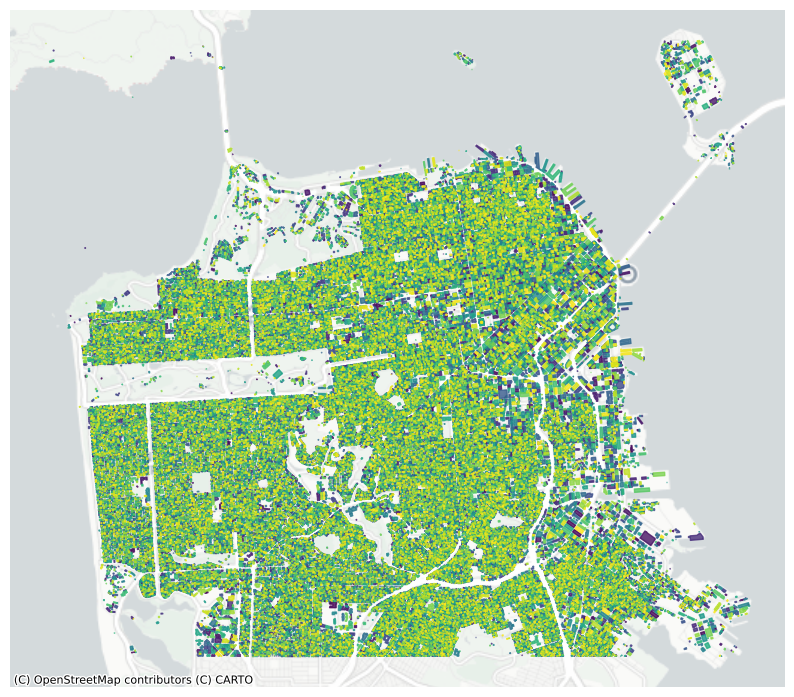

In [0]:
# Render the DENSEST shard (most bytes) so the demo shows real buildings — sorting by size
# skips the near-empty edge shards (e.g. the coastal NW tile with a handful of buildings).
# City-scale shards carry full z16 detail and far exceed the interactive embed ceiling
# (~4-5 MB), so show_pmtiles renders them as a STATIC map — enough to confirm the shard's
# bounded, disjoint extent (see the §6 note above).
_by_size = sorted(shard_paths.items(), key=lambda kv: os.path.getsize(kv[1]), reverse=True)
_shard_id, _shard_path = _by_size[0]
print(f"... rendering densest shard: {_shard_id}")
show_pmtiles(_shard_path)

... rendering shard: 11_327_792
... pmtiles: type=mvt zoom=11-16 bounds=(-122.5195312, 37.5794125, -122.34375, 37.7185903)
[vizx] layer[0] 0.0MB = 14.4MB > 0MB → static fallback


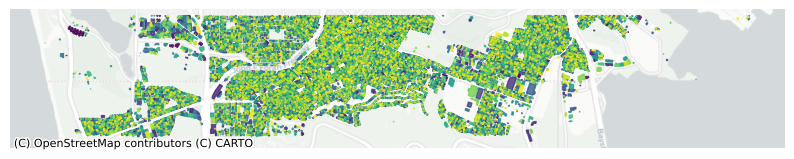

In [0]:
# Render the next-densest shard to visually confirm the bounded, disjoint extents
# (a different quarter of the city, its own non-overlapping bounds).
if len(_by_size) > 1:
    _shard_id2, _shard_path2 = _by_size[1]
    print(f"... rendering shard: {_shard_id2}")
    show_pmtiles(_shard_path2)
else:
    print("... only one shard present (re-run with a wider AOI to see multiple)")

## What we built

| Artifact | Location | Description |
|---|---|---|
| `sf_buildings_mvt_shards_src` (Delta) | managed table | `(z, x, y, mvt_bytes, shard)` pyramid rows, z11–z16 |
| `sf_building_shards` (Delta) | managed table | shard catalog: bounds + zoom range + Volume path |
| `{shard_id}.pmtiles` (Volume) | `HELIOS_DIR/buildings_shards/` | one bounded PMTiles archive per shard |
| `mosaic.json` (Volume) | `HELIOS_DIR/` | TileJSON-style manifest; maps shard bounds → archive path |

**When to use sharding vs a single archive:**

- **Single archive** (Notebook 01) — city-scale data that fits comfortably in one
  file (< ~2 GB); fastest to generate and serve.
- **Distributed sharding** (this notebook) — statewide, national, or global data;
  when any sub-region updates independently; when parallel workers must avoid write
  contention; when you want atomic per-region re-generation without touching the rest
  of the dataset.

The `mosaic.json` is the bridge: a lightweight catalog that lets the client assemble
the full multi-region map from the correct subset of archives for any viewport —
no tile-proxy server, no merge step, no global re-write when a neighbourhood changes.

**Next:** Notebook 02 drapes NAIP aerial imagery behind these footprints as a visual
basemap; Notebook 03 adds solar-yield terrain scoring.